In [163]:
import pandas as pd
import numpy as np
import seaborn as sns
import ast
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
from torchmetrics import Accuracy
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.optim as optim


In [90]:
df_1 = pd.read_csv('Model_tunning/model_tunning_trial_1.csv', parse_dates = True, index_col=0)
df_2 = pd.read_csv('Model_tunning/model_tunning_trial_2.csv', parse_dates = True, index_col=0)

df_1 = pd.concat([df_1,df_2])

df_1 = df_1[df_1['type']  == "nested"] # consider only nested runs

df_1 = df_1[["params", "metrics"]]
df_1.reset_index(drop=True, inplace=True)

df_1['params'] = df_1['params'].apply(ast.literal_eval)



C:\Users\Gediy\AppData\Local\Temp\ipykernel_3956\30532570.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_1 = pd.read_csv('Model_tunning/model_tunning_trial_1.csv', parse_dates = True, index_col=0)
C:\Users\Gediy\AppData\Local\Temp\ipykernel_3956\30532570.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_2 = pd.read_csv('Model_tunning/model_tunning_trial_2.csv', parse_dates = True, index_col=0)


In [91]:
# Function to preprocess and replace inf and nan with "None"
def preprocess_metrics(value):
    if isinstance(value, str):
        # Replace 'inf' and 'nan' with "None"
        value = value.replace('inf', '"None"').replace('nan', '"None"')
    return value

# Apply preprocessing function
df_1['metrics'] = df_1['metrics'].apply(preprocess_metrics)

# Now try to evaluate the metrics string into a dictionary using ast.literal_eval
def safe_literal_eval(value):
    try:
        return ast.literal_eval(value)  # Convert the string to a dictionary
    except (ValueError, SyntaxError) as e:
        print(f"Error parsing value: {value}")
        return None

# Apply safe literal eval to metrics column
df_1['metrics'] = df_1['metrics'].apply(safe_literal_eval)



In [71]:
# Extract 'n_layers' from 'params' and 'lowest_val_loss' from 'metrics'
df_1['n_layers'] = df_1['params'].apply(lambda x: x.get('params.n_layers', None))
df_1['lowest_val_loss'] = df_1['metrics'].apply(lambda x: x.get('metrics.lowest_val_loss', None))

# Drop rows with None values in 'n_layers' or 'lowest_val_loss'
df_1 = df_1.dropna(subset=['n_layers', 'lowest_val_loss'])

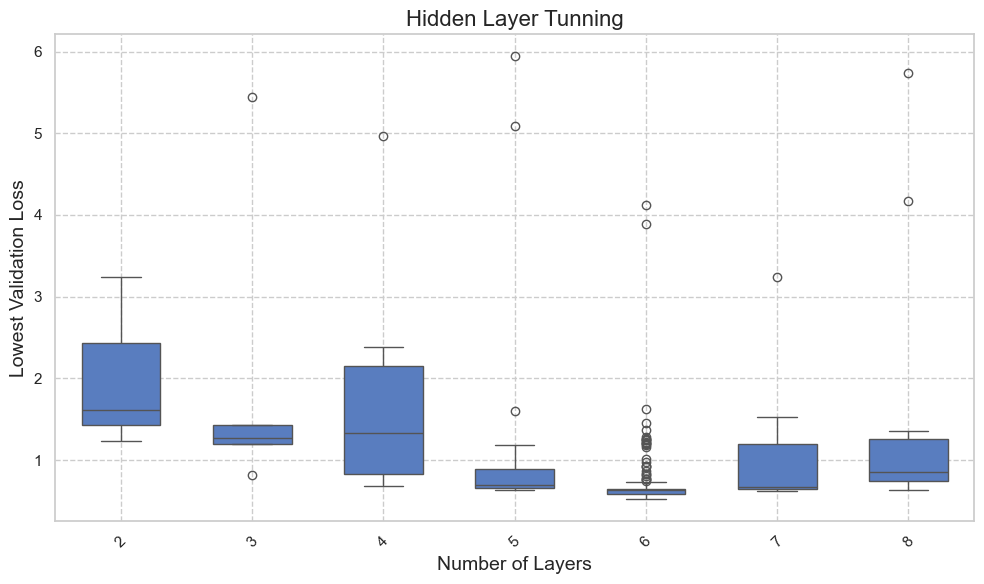

In [72]:
# Sort the DataFrame by 'n_layers'
df_1 = df_1.sort_values(by='n_layers') 

# Set Seaborn style
sns.set(style="whitegrid", palette="muted")

# Create the plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='n_layers', y='lowest_val_loss', data=df_1, width=0.6)

# Add titles and labels
plt.title('Hidden Layer Tunning', fontsize=16)
plt.xlabel('Number of Layers', fontsize=14)
plt.ylabel('Lowest Validation Loss', fontsize=14)

# Rotate x-axis labels for better readability (if needed)
plt.xticks(rotation=45)

# Add gridlines for clarity
plt.grid(True, linestyle='--', linewidth=1.0)

# Show the plot
plt.tight_layout()
plt.show()

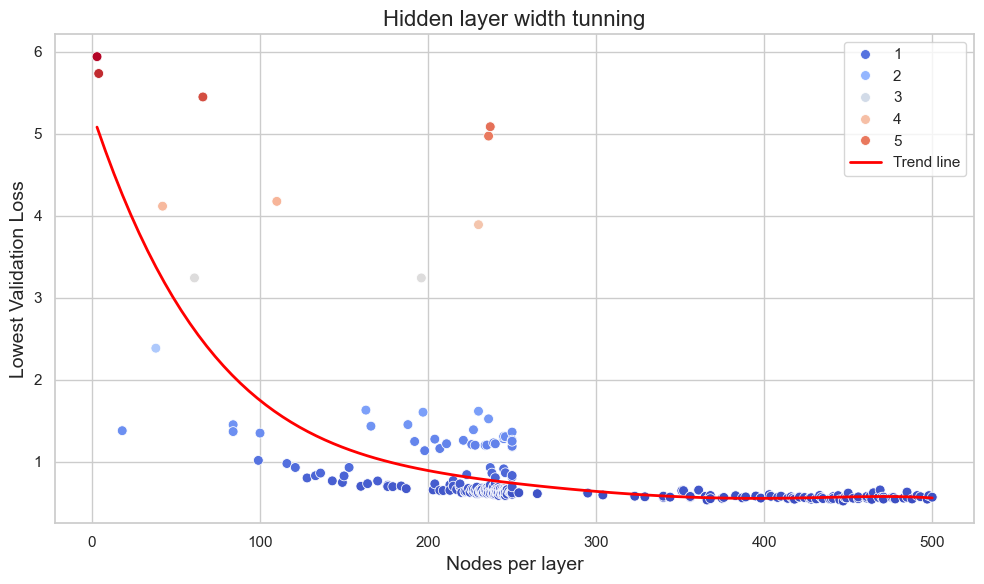

In [87]:
# Extract 'hidden_units' from 'params' and 'lowest_val_loss' from 'metrics'
df_1['hidden_units'] = df_1['params'].apply(lambda x: x.get('params.hidden_units', None))
df_1['lowest_val_loss'] = df_1['metrics'].apply(lambda x: x.get('metrics.lowest_val_loss', None))

# Convert to numeric, coerce invalid values to NaN
df_1['hidden_units'] = pd.to_numeric(df_1['hidden_units'], errors='coerce')
df_1['lowest_val_loss'] = pd.to_numeric(df_1['lowest_val_loss'], errors='coerce')

# Drop rows with None values in 'hidden_units' or 'lowest_val_loss'
df_1 = df_1.dropna(subset=['hidden_units', 'lowest_val_loss'])

# Sort the DataFrame by 'n_layers'
df_1 = df_1.sort_values(by='hidden_units') 

# Fit a polynomial curve (degree 2 for a quadratic fit)
x = df_1['hidden_units'].values
y = df_1['lowest_val_loss'].values

# Polynomial fit (degree 2)
coeffs = np.polyfit(x, y, 5)
poly = np.poly1d(coeffs)

# Generate points for the fitted curve
x_fit = np.linspace(min(x), max(x), 100)
y_fit = poly(x_fit)

# Set Seaborn style
sns.set(style="whitegrid", palette="muted")

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='hidden_units', y='lowest_val_loss', data=df_1, hue='lowest_val_loss', palette="coolwarm", s=50)

# Plot the fitted curve as a line
plt.plot(x_fit, y_fit, color='red', label='Trend line', linewidth=2)

# Add titles and labels
plt.title('Hidden layer width tunning', fontsize=16)
plt.xlabel('Nodes per layer', fontsize=14)
plt.ylabel('Lowest Validation Loss', fontsize=14)

# Show the legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [88]:
# Display the polynomial formula
formula = f"y = {coeffs[0]:.4f}x^5+ {coeffs[1]:.4f}x4 + {coeffs[2]:.4f}x3 + {coeffs[3]:.4f}x^2 + {coeffs[4]:.4f}x + {coeffs[5]:.4f}"
print(f"Fitted Polynomial Formula: {formula}")

Fitted Polynomial Formula: y = -0.0000x^5+ 0.0000x4 + -0.0000x3 + 0.0004x^2 + -0.0619x + 5.2626


Fitted Polynomial Formula: 21242109822879.3945x4 + -55480788057.5528x3 + 52450754.2079x^2 + -20690.6145x + 3.5333


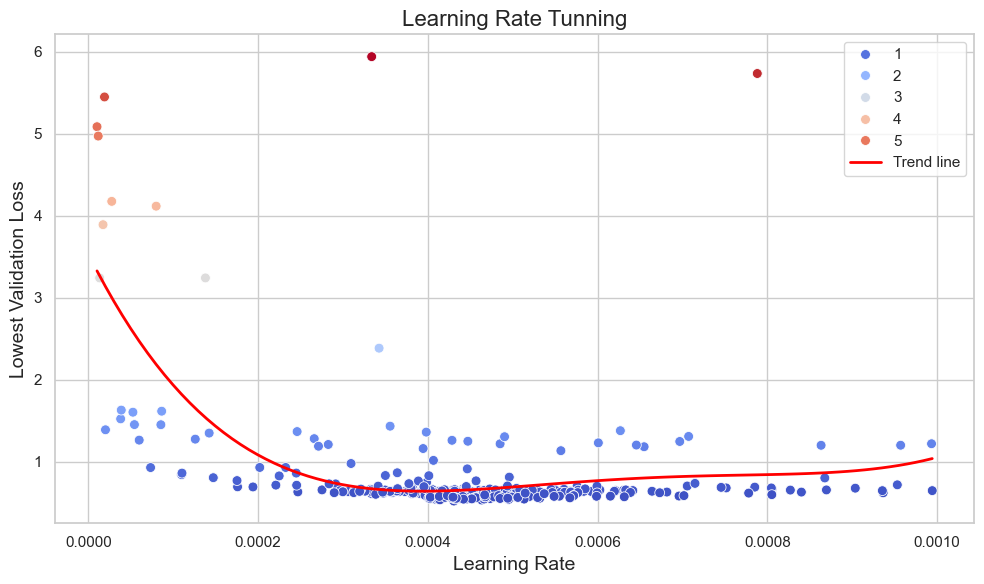

In [107]:
# Extract 'learning_rate' from 'params' and 'lowest_val_loss' from 'metrics'
df_1['learning_rate'] = df_1['params'].apply(lambda x: x.get('params.learning rate', None))
df_1['lowest_val_loss'] = df_1['metrics'].apply(lambda x: x.get('metrics.lowest_val_loss', None))

# Convert to numeric, coerce invalid values to NaN
df_1['learning_rate'] = pd.to_numeric(df_1['learning_rate'], errors='coerce')
df_1['lowest_val_loss'] = pd.to_numeric(df_1['lowest_val_loss'], errors='coerce')

# Drop rows with NaN values in 'learning_rate' or 'lowest_val_loss'
df_1 = df_1.dropna(subset=['learning_rate', 'lowest_val_loss'])

# Fit a polynomial curve (degree 2 for a quadratic fit)
x = df_1['learning_rate'].values
y = df_1['lowest_val_loss'].values

# Polynomial fit (degree 2)
coeffs = np.polyfit(x, y, 4)
poly = np.poly1d(coeffs)

# Display the polynomial formula
formula = f"{coeffs[0]:.4f}x4 + {coeffs[1]:.4f}x3 + {coeffs[2]:.4f}x^2 + {coeffs[3]:.4f}x + {coeffs[4]:.4f}"
print(f"Fitted Polynomial Formula: {formula}")

# Generate points for the fitted curve
x_fit = np.linspace(min(x), max(x), 100)
y_fit = poly(x_fit)

# Set Seaborn style
sns.set(style="whitegrid", palette="muted")

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='learning_rate', y='lowest_val_loss', data=df_1, hue='lowest_val_loss', palette="coolwarm", s=50)

# Plot the fitted curve as a line
plt.plot(x_fit, y_fit, color='red', label='Trend line', linewidth=2)

# Add titles and labels
plt.title('Learning Rate Tunning', fontsize=16)
plt.xlabel('Learning Rate', fontsize=14)
plt.ylabel('Lowest Validation Loss', fontsize=14)

# Show the legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

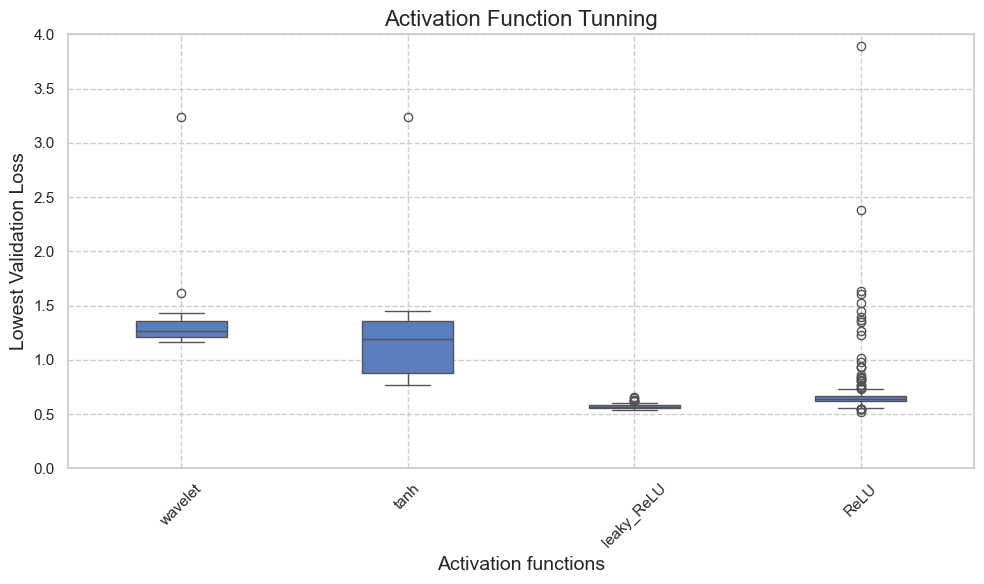

In [115]:
# Extract 'n_layers' from 'params' and 'lowest_val_loss' from 'metrics'
df_1['activation'] = df_1['params'].apply(lambda x: x.get('params.activation', None))
df_1['lowest_val_loss'] = df_1['metrics'].apply(lambda x: x.get('metrics.lowest_val_loss', None))

# Drop rows with None values in 'n_layers' or 'lowest_val_loss'
df_1 = df_1.dropna(subset=['activation', 'lowest_val_loss'])

# Set Seaborn style
sns.set(style="whitegrid", palette="muted")

# Create the plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='activation', y='lowest_val_loss', data=df_1, width=0.4, order=["wavelet", "tanh", "leaky_ReLU", "ReLU"])

# Set the y-axis range (for example, from 0.5 to 1.0)
plt.ylim(0.0, 4.0)

# Add titles and labels
plt.title('Activation Function Tunning', fontsize=16)
plt.xlabel('Activation functions', fontsize=14)
plt.ylabel('Lowest Validation Loss', fontsize=14)

# Rotate x-axis labels for better readability (if needed)
plt.xticks(rotation=45)

# Add gridlines for clarity
plt.grid(True, linestyle='--', linewidth=1.0)

# Show the plot
plt.tight_layout()
plt.show()


Note that: Leaky_ReLU activation function was tested for higher batch size and best number of layer.

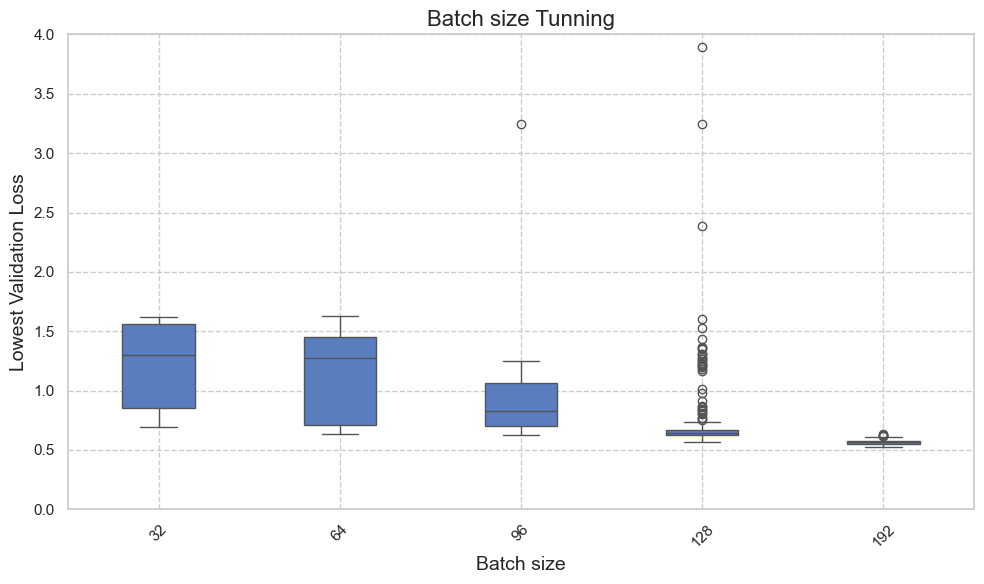

In [120]:
# Extract 'n_layers' from 'params' and 'lowest_val_loss' from 'metrics'
df_1['batch_size'] = df_1['params'].apply(lambda x: x.get('params.batch_size', None))
df_1['lowest_val_loss'] = df_1['metrics'].apply(lambda x: x.get('metrics.lowest_val_loss', None))

# Drop rows with None values in 'n_layers' or 'lowest_val_loss'
df_1 = df_1.dropna(subset=['batch_size', 'lowest_val_loss'])

# Sort the DataFrame by 'n_layers'
df_1 = df_1.sort_values(by='batch_size') 

# Set Seaborn style
sns.set(style="whitegrid", palette="muted")

# Create the plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='batch_size', y='lowest_val_loss', data=df_1, width=0.4, order=[32, 64, 96, 128, 192])

# Set the y-axis range (for example, from 0.5 to 1.0)
plt.ylim(0.0, 4.0)

# Add titles and labels
plt.title('Batch size Tunning', fontsize=16)
plt.xlabel('Batch size', fontsize=14)
plt.ylabel('Lowest Validation Loss', fontsize=14)

# Rotate x-axis labels for better readability (if needed)
plt.xticks(rotation=45)

# Add gridlines for clarity
plt.grid(True, linestyle='--', linewidth=1.0)

# Show the plot
plt.tight_layout()
plt.show()


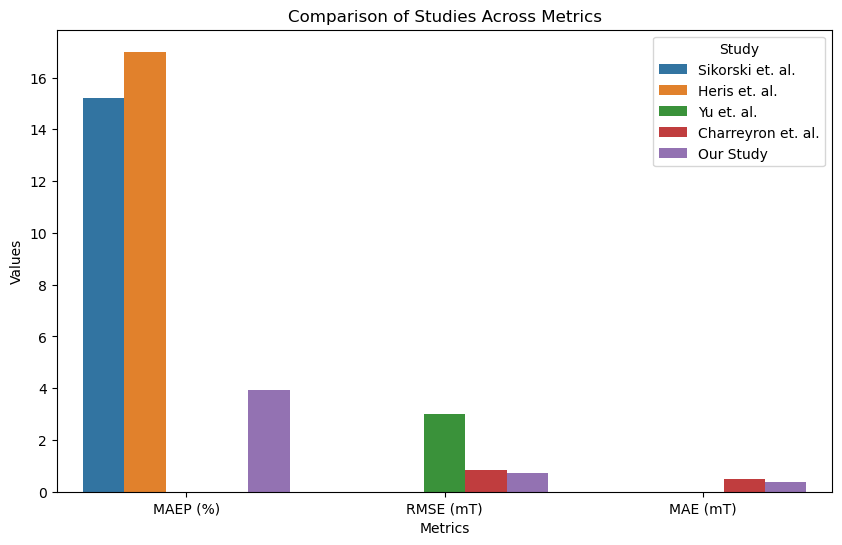

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = {
    'Study': ['Sikorski et. al.', 'Heris et. al.', 'Yu et. al.', 'Charreyron et. al.', 'Our Study'],
    'MAEP (%)': [15.21, 17.00, None, None, 3.94],
    'RMSE (mT)': [None, None, 3.01, 0.83, 0.71],
    'MAE (mT)': [None, None, None, 0.51, 0.38]
}
df = pd.DataFrame(data)

# Melt the data for plotting
df_melted = df.melt(id_vars='Study', var_name='Metric', value_name='Value')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Metric', y='Value', hue='Study')
plt.title('Comparison of Studies Across Metrics')
plt.ylabel('Values')
plt.xlabel('Metrics')
plt.legend(title='Study')
plt.show()


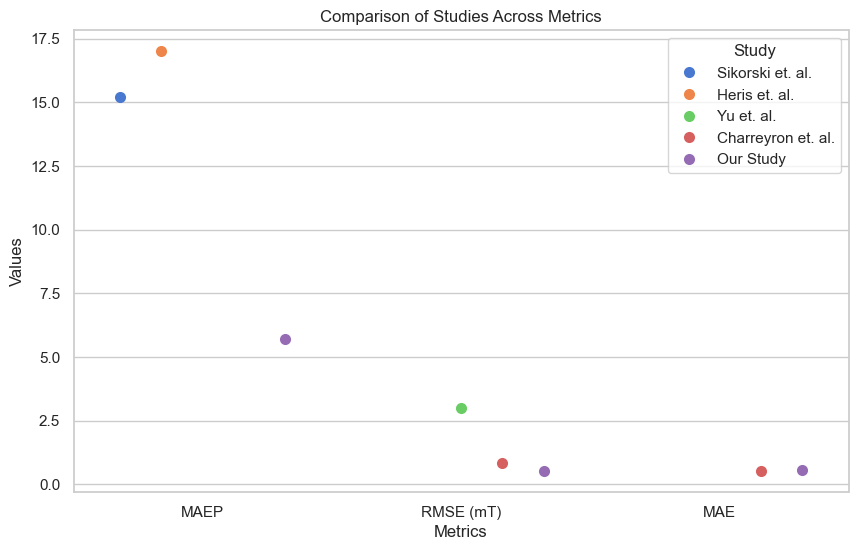

In [122]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=df_melted, x='Metric', y='Value', hue='Study', dodge=True, size=8)
plt.title('Comparison of Studies Across Metrics')
plt.ylabel('Values')
plt.xlabel('Metrics')
plt.legend(title='Study')
plt.show()


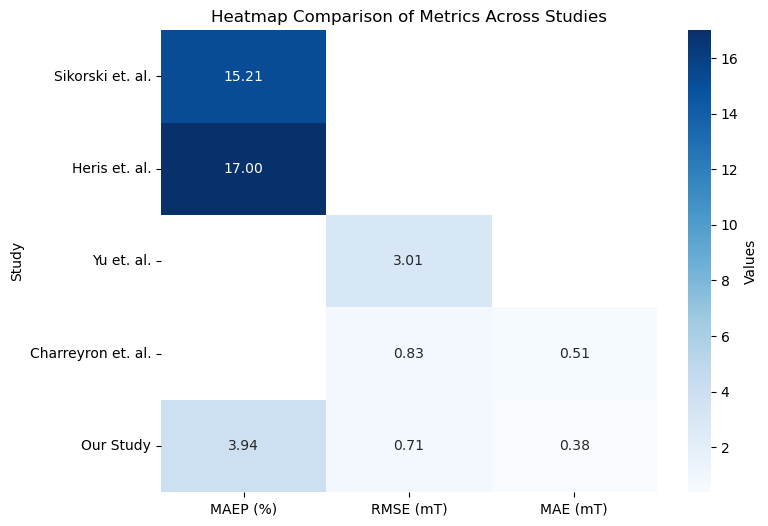

In [2]:
import numpy as np

# Replace None with NaN for heatmap
df_numeric = df.set_index('Study').replace({None: np.nan})

plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric, annot=True, cmap='Blues', fmt=".2f", cbar_kws={'label': 'Values'})
plt.title('Heatmap Comparison of Metrics Across Studies')
plt.show()


In [134]:
# Get cpu or gpu for training.
device = "cuda" if torch.cuda.is_available() else "cpu"

In [137]:
print("Is CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("PyTorch version:", torch.__version__)

Is CUDA available: False
CUDA version: 11.8
PyTorch version: 2.5.1


In [278]:
# loading best_cmd_model
model = torch.load("Model_tunning/best_cmdCurrent_model.pth", map_location=torch.device('cpu'))

C:\Users\Gediy\AppData\Local\Temp\ipykernel_3956\195669176.py:2: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



In [279]:
# importing test dataset
df1_clean = pd.read_csv('superposition_test/test1_measured.csv', parse_dates = True, index_col=0)  #  table data
df2_clean = pd.read_csv('superposition_test/test2_measured.csv', parse_dates = True, index_col=0)  #  table data
df3_clean = pd.read_csv('superposition_test/test3_measured.csv', parse_dates = True, index_col=0)  #  table data

In [288]:
def Quiver_plot(grid_pts,field_predicted):

    plt.style.use('_mpl-gallery')

    # Make data
    
    x = grid_pts[:,0]
    y = grid_pts[:,1]
    z = grid_pts[:,2]

    U = field_predicted[:,0]

    V = field_predicted[:,1]

    W = field_predicted[:,2]

    # Compute the magnitude of the vectors
    magnitude = np.sqrt(U**2 + V**2 + W**2)
    
    print(np.max(magnitude))

    # Normalize the magnitudes to the range [0, 1]
    norm = Normalize(vmin=magnitude.min(), vmax=magnitude.max())

    # Create a colormap object
    colormap = cm.winter_r # You can choose other colormaps like 'plasma', 'inferno', etc.


    # Plot
    # Create a figure with custom size
    fig = plt.figure(figsize=(12, 8))  # Set figure size
    ax = fig.add_subplot(111, projection='3d')

    plot = ax.quiver(x, y, z, U, V, W, length=0.002, normalize= False, color=colormap(norm(magnitude)))

    # Add a colorbar to show the mapping of magnitudes to colors
    mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
    cbar = plt.colorbar(mappable, ax=ax)
    cbar.set_label('Magnitude [mT]')

    ax.set(xticklabels=[],
        yticklabels=[],
        zticklabels=[],
        xlabel = ('X axis [m]'),
        ylabel = ('Y axis [m]'),
        zlabel = ('Z axis [m]'),
        title = ('Magnetic flux [mT]'))

    plt.show()

In [276]:
def Analyze_model(data):
        x = data[['Sensor_1_dir_x','Sensor_2_dir_x','Sensor_3_dir_x','Sensor_4_dir_x',
                'Sensor_5_dir_x','Sensor_6_dir_x','Sensor_7_dir_x','Sensor_8_dir_x',
                'Sensor_9_dir_x','Sensor_10_dir_x','Sensor_11_dir_x','Sensor_12_dir_x',
                'Sensor_13_dir_x','Sensor_14_dir_x','Sensor_15_dir_x','Sensor_16_dir_x']].values.reshape(-1, 1)

        y = data[['Sensor_1_dir_y','Sensor_2_dir_y','Sensor_3_dir_y','Sensor_4_dir_y',
                'Sensor_5_dir_y','Sensor_6_dir_y','Sensor_7_dir_y','Sensor_8_dir_y',
                'Sensor_9_dir_y','Sensor_10_dir_y','Sensor_11_dir_y','Sensor_12_dir_y',
                'Sensor_13_dir_y','Sensor_14_dir_y','Sensor_15_dir_y','Sensor_16_dir_y']].values.reshape(-1, 1)

        z = data[['Sensor_1_dir_z','Sensor_2_dir_z','Sensor_3_dir_z','Sensor_4_dir_z',
                'Sensor_5_dir_z','Sensor_6_dir_z','Sensor_7_dir_z','Sensor_8_dir_z',
                'Sensor_9_dir_z','Sensor_10_dir_z','Sensor_11_dir_z','Sensor_12_dir_z',
                'Sensor_13_dir_z','Sensor_14_dir_z','Sensor_15_dir_z','Sensor_16_dir_z']].values.reshape(-1, 1)

        grid_pts = np.hstack((x,y,z))
        #grid_pts = np.vstack((grid_pts))

        cmdCurrent = data[["cmdCoilCurrent_1(A)","cmdCoilCurrent_2(A)","cmdCoilCurrent_3(A)","cmdCoilCurrent_4(A)",
                           "cmdCoilCurrent_5(A)","cmdCoilCurrent_6(A)", "cmdCoilCurrent_7(A)", "cmdCoilCurrent_8(A)"]].values
        
        cmdCurrent = np.repeat(cmdCurrent, 16, axis=0).reshape(-1, cmdCurrent.shape[1]) # repeat the cmdCurrent for each row and reshape it to match the grid pts
        
        model_input = np.hstack((cmdCurrent,grid_pts)) # combine cmdCurrent with grid pts to form inpput vector for our model
        
        model_input = torch.tensor(model_input, dtype=torch.float32)

        

        
        prediction = model(model_input).detach().numpy() # converting prediction to numpy array
                
                
        Quiver_plot(grid_pts,prediction) 
        U1 = prediction[:,0]  
        V1 = prediction[:,1]
        W1 = prediction[:,2]
        
        
        U_measured = data[['sensor_1_X [mT]','sensor_2_X [mT]','sensor_3_X [mT]','sensor_4_X [mT]',
                    'sensor_5_X [mT]','sensor_6_X [mT]','sensor_7_X [mT]','sensor_8_X [mT]',
                    'sensor_9_X [mT]','sensor_10_X [mT]','sensor_11_X [mT]','sensor_12_X [mT]',
                    'sensor_13_X [mT]','sensor_14_X [mT]','sensor_15_X [mT]','sensor_16_X [mT]']].values.reshape(-1, 1)

        V_measured = data[['sensor_1_Y [mT]','sensor_2_Y [mT]','sensor_3_Y [mT]','sensor_4_Y [mT]',
                        'sensor_5_Y [mT]','sensor_6_Y [mT]','sensor_7_Y [mT]','sensor_8_Y [mT]',
                        'sensor_9_Y [mT]','sensor_10_Y [mT]','sensor_11_Y [mT]','sensor_12_Y [mT]',
                        'sensor_13_Y [mT]','sensor_14_Y [mT]','sensor_15_Y [mT]','sensor_16_Y [mT]',]].values.reshape(-1, 1)


        W_measured = data[['sensor_1_Z [mT]','sensor_2_Z [mT]','sensor_3_Z [mT]','sensor_4_Z [mT]',
                        'sensor_5_Z [mT]','sensor_6_Z [mT]','sensor_7_Z [mT]','sensor_8_Z [mT]',
                        'sensor_9_Z [mT]','sensor_10_Z [mT]','sensor_11_Z [mT]','sensor_12_Z [mT]',
                        'sensor_13_Z [mT]','sensor_14_Z [mT]','sensor_15_Z [mT]','sensor_16_Z [mT]',]].values.reshape(-1, 1)
        
        
        U_error = U_measured - U1
        V_error = V_measured - V1
        W_error = W_measured - W1
        
        # Orientation error

        M_measured = np.sqrt(U_measured**2 + V_measured**2 + W_measured**2)   # magnitude 
        M1 = np.sqrt(U1**2 + V1**2 + W1**2) # magnitude

        H_measured = np.sqrt(U_measured**2 + V_measured**2)   # magnitude in the horizontal plane
        H1 = np.sqrt(U1**2 + V1**2)  # magnitude in the horizontal plane

        with np.errstate(divide='ignore', invalid='ignore'):
                phi_measured = np.arcsin(np.nan_to_num(W_measured/M_measured, nan = 0, posinf=0, neginf=0))  # orientation of the magnetic field relative to the horizontal plane
                phi1 = np.arcsin(np.nan_to_num(W1/M1,nan = 0, posinf=0, neginf=0))

                theta_measured = np.arcsin(np.nan_to_num(V_measured/H_measured, nan = 0, posinf=0, neginf=0)) # orientation of the magnetic field relative to the x-axis
                theta1 = np.arcsin(np.nan_to_num(V1/H1,nan = 0, posinf=0, neginf=0))

        phi_error = phi_measured - phi1
        theta_error = theta_measured - theta1
        
        
        # mean absolute error calculation
        U_abs_error = np.mean(np.abs(U_error))
        V_abs_error = np.mean(np.abs(V_error))
        W_abs_error = np.mean(np.abs(W_error))
        M_abs_error = np.mean(np.abs(M1-M_measured))

        print('U_MAE: ', U_abs_error)
        print('V_MAE: ', V_abs_error)
        print('W_MAE: ', W_abs_error)
        print('M_MAE: ', M_abs_error)
        
        
        # Mean Absolute Percentage Error calculation
        with np.errstate(divide='ignore', invalid='ignore'): # to ignor the error prompt when dividing by zero
                U_MAPE = np.mean(np.abs(np.nan_to_num(U_error/U_measured, nan = 0, posinf=0, neginf=0))*100)
                V_MAPE = np.mean(np.abs(np.nan_to_num(V_error/V_measured, nan = 0, posinf=0, neginf=0))*100)
                W_MAPE = np.mean(np.abs(np.nan_to_num(W_error/W_measured, nan = 0, posinf=0, neginf=0))*100)
                M_MAPE = np.mean(np.abs(np.nan_to_num((M1-M_measured)/M_measured, nan = 0, posinf=0, neginf=0))*100)

        print('U_MAPE: ', U_MAPE)
        print('V_MAPE: ', V_MAPE)
        print('W_MAPE: ', W_MAPE)
        print('M_MAPE: ', M_MAPE)
        
        
        # mean absolute error for the orientaion
        phi_abs_error = np.mean(np.abs(phi_error))
        theta_abs_error = np.mean(np.abs(theta_error))

        print('phi_MAE: ', phi_abs_error, "(", np.degrees(phi_abs_error),")")
        print('theta_MAE: ', theta_abs_error, "(", np.degrees(theta_abs_error),")")

In [277]:
Analyze_model(df1_clean)

TypeError: 'str' object is not callable

47.539577


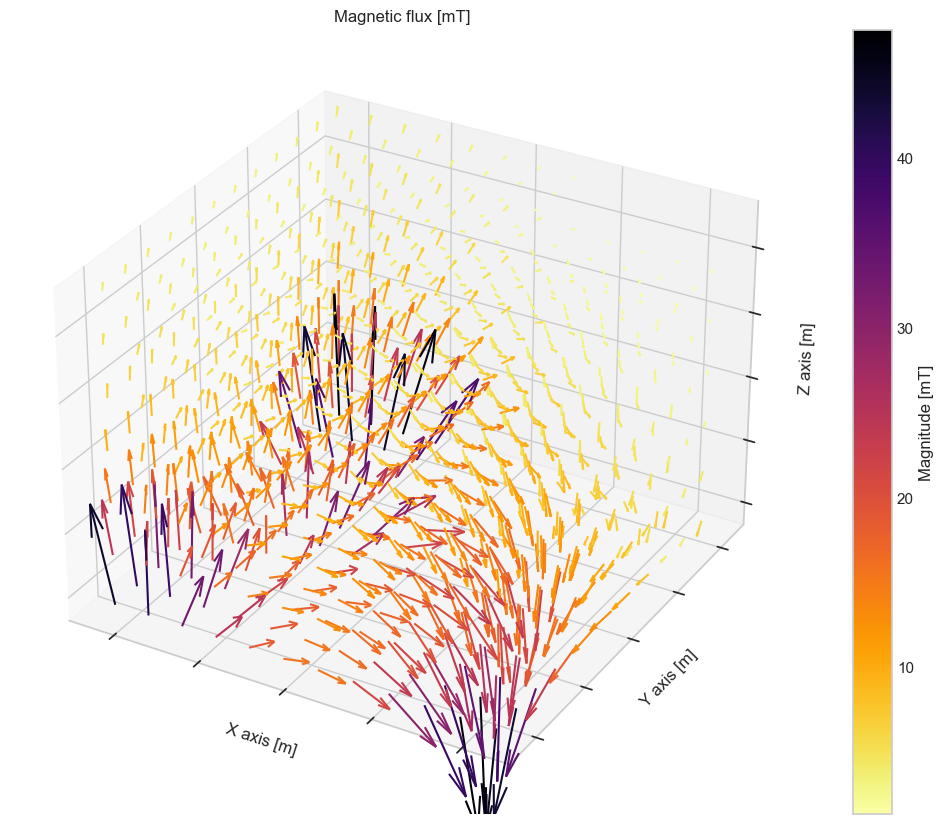

U_MAE:  6.161911460719179
V_MAE:  2.8209790042275142
W_MAE:  10.37770951606669
M_MAE:  8.255945863121358
U_MAPE:  331.5766405527493
V_MAPE:  578.5437244146071
W_MAPE:  551.8717157444895
M_MAPE:  98.1502644242024
phi_MAE:  0.9682712162081677 ( 55.477854112727236 )
theta_MAE:  0.5609736219209007 ( 32.14142095423513 )


In [167]:
Analyze_model(df2_clean)

54.70291


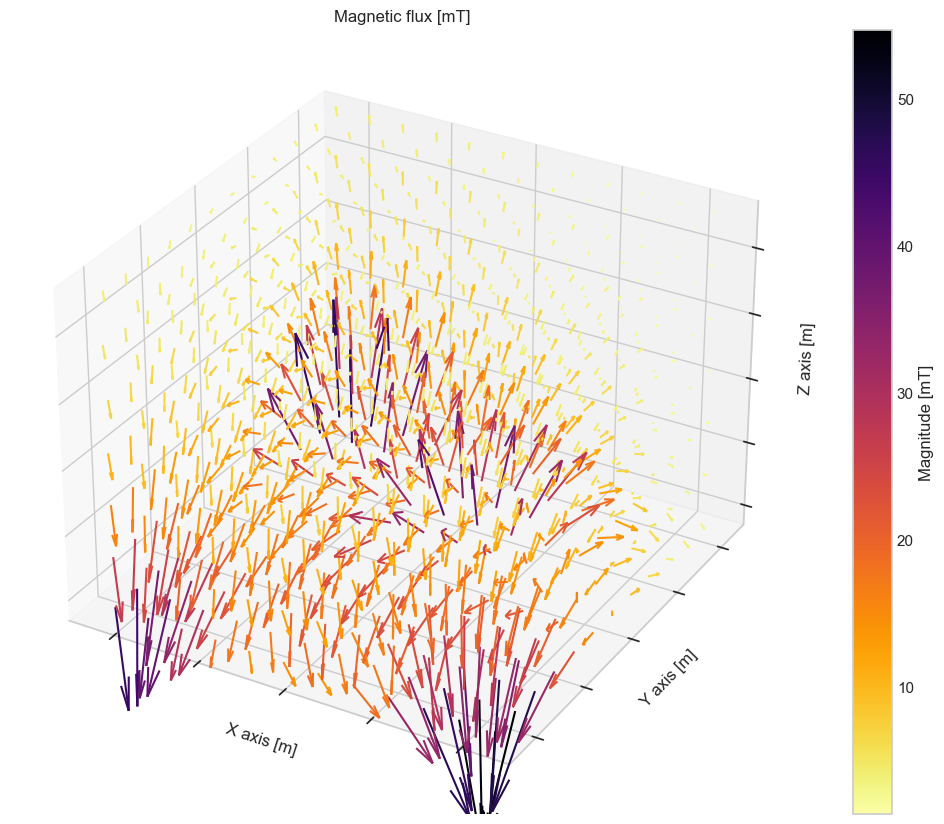

U_MAE:  3.045373830271025
V_MAE:  6.645197713438095
W_MAE:  10.802514437732704
M_MAE:  8.870561087598425
U_MAPE:  604.0370869084952
V_MAPE:  416.3761698283095
W_MAPE:  753.5366748702058
M_MAPE:  113.55609870085867
phi_MAE:  0.9718276972360504 ( 55.68162546554327 )
theta_MAE:  0.653382899721545 ( 37.436082560064015 )


In [168]:
Analyze_model(df3_clean)

In [280]:
def Analyze_model(data):
        x = data[['Sensor_1_dir_x','Sensor_2_dir_x','Sensor_3_dir_x','Sensor_4_dir_x',
                'Sensor_5_dir_x','Sensor_6_dir_x','Sensor_7_dir_x','Sensor_8_dir_x',
                'Sensor_9_dir_x','Sensor_10_dir_x','Sensor_11_dir_x','Sensor_12_dir_x',
                'Sensor_13_dir_x','Sensor_14_dir_x','Sensor_15_dir_x','Sensor_16_dir_x']].values.reshape(-1, 1)

        y = data[['Sensor_1_dir_y','Sensor_2_dir_y','Sensor_3_dir_y','Sensor_4_dir_y',
                'Sensor_5_dir_y','Sensor_6_dir_y','Sensor_7_dir_y','Sensor_8_dir_y',
                'Sensor_9_dir_y','Sensor_10_dir_y','Sensor_11_dir_y','Sensor_12_dir_y',
                'Sensor_13_dir_y','Sensor_14_dir_y','Sensor_15_dir_y','Sensor_16_dir_y']].values.reshape(-1, 1)

        z = data[['Sensor_1_dir_z','Sensor_2_dir_z','Sensor_3_dir_z','Sensor_4_dir_z',
                'Sensor_5_dir_z','Sensor_6_dir_z','Sensor_7_dir_z','Sensor_8_dir_z',
                'Sensor_9_dir_z','Sensor_10_dir_z','Sensor_11_dir_z','Sensor_12_dir_z',
                'Sensor_13_dir_z','Sensor_14_dir_z','Sensor_15_dir_z','Sensor_16_dir_z']].values.reshape(-1, 1)

        grid_pts = np.hstack((x,y,z))
        #grid_pts = np.vstack((grid_pts))

        cmdCurrent = data[["cmdCoilCurrent_1(A)","cmdCoilCurrent_2(A)","cmdCoilCurrent_3(A)","cmdCoilCurrent_4(A)",
                           "cmdCoilCurrent_5(A)","cmdCoilCurrent_6(A)", "cmdCoilCurrent_7(A)", "cmdCoilCurrent_8(A)"]].values
        
        cmdCurrent = np.repeat(cmdCurrent, 16, axis=0).reshape(-1, cmdCurrent.shape[1]) # repeat the cmdCurrent for each row and reshape it to match the grid pts
        
        model_input = np.hstack((cmdCurrent,grid_pts)) # combine cmdCurrent with grid pts to form inpput vector for our model
        
        model_input = torch.tensor(model_input, dtype=torch.float32)

        

        
        prediction = model(model_input)
                
                
        Quiver_plot(grid_pts,prediction.detach().numpy()) 

        
        
        U_measured = data[['sensor_1_X [mT]','sensor_2_X [mT]','sensor_3_X [mT]','sensor_4_X [mT]',
                    'sensor_5_X [mT]','sensor_6_X [mT]','sensor_7_X [mT]','sensor_8_X [mT]',
                    'sensor_9_X [mT]','sensor_10_X [mT]','sensor_11_X [mT]','sensor_12_X [mT]',
                    'sensor_13_X [mT]','sensor_14_X [mT]','sensor_15_X [mT]','sensor_16_X [mT]']].values.reshape(-1, 1)

        V_measured = data[['sensor_1_Y [mT]','sensor_2_Y [mT]','sensor_3_Y [mT]','sensor_4_Y [mT]',
                        'sensor_5_Y [mT]','sensor_6_Y [mT]','sensor_7_Y [mT]','sensor_8_Y [mT]',
                        'sensor_9_Y [mT]','sensor_10_Y [mT]','sensor_11_Y [mT]','sensor_12_Y [mT]',
                        'sensor_13_Y [mT]','sensor_14_Y [mT]','sensor_15_Y [mT]','sensor_16_Y [mT]',]].values.reshape(-1, 1)


        W_measured = data[['sensor_1_Z [mT]','sensor_2_Z [mT]','sensor_3_Z [mT]','sensor_4_Z [mT]',
                        'sensor_5_Z [mT]','sensor_6_Z [mT]','sensor_7_Z [mT]','sensor_8_Z [mT]',
                        'sensor_9_Z [mT]','sensor_10_Z [mT]','sensor_11_Z [mT]','sensor_12_Z [mT]',
                        'sensor_13_Z [mT]','sensor_14_Z [mT]','sensor_15_Z [mT]','sensor_16_Z [mT]',]].values.reshape(-1, 1)
        
        
        B_measured = torch.tensor(np.hstack([U_measured,V_measured,W_measured]), dtype=torch.float32)
        
        
        def metrics_fn(outputs, labels):
            RMSE = torch.sqrt(torch.mean((labels-outputs)**2,dim= 0, keepdim=False))
            
            
            MAE = torch.mean(torch.abs(labels-outputs),dim= 0, keepdim=False)
            
            labels = torch.where(labels == 0, torch.tensor(1e-6), labels) # to avoid division by zero
            
            percentage_error = (labels-outputs)/labels            
            MAEP = torch.mean(torch.abs(percentage_error),dim= 0, keepdim=False)
                 
            output_norm = torch.norm(outputs, p=2, dim=1, keepdim=False, out=None)
            labels_norm = torch.norm(labels, p=2, dim=1, keepdim=False, out=None)
            
            RMSE_norm = torch.sqrt(torch.mean((labels_norm-output_norm)**2))
                   
            MAE_norm = torch.mean(torch.abs(labels_norm-output_norm),dim= 0, keepdim=False) # mean absolute error 
            
            percentage_error_norm = (labels_norm - output_norm)/labels_norm
            MAEP_norm = torch.mean(torch.abs(percentage_error_norm)) # mean absolute error
            
            
            labels_norm = torch.where(labels_norm== 0, torch.tensor(1e-6), labels_norm) # to avoid division by zero
            output_norm = torch.where(output_norm == 0, torch.tensor(1e-6), output_norm) # to avoid division by zero
            
            
            phi_measured = torch.arcsin(labels[:,2]/labels_norm) # orientation of the magnetic field relative to the horizontal plane
            phi1 = torch.arcsin(outputs[:,2]/output_norm)
            
            label_h_norm = torch.sqrt(labels[:,0]**2 + labels[:,1]**2)
            output_h_norm = torch.sqrt(outputs[:,0]**2 + outputs[:,1]**2)
            
            label_h_norm = torch.where(label_h_norm == 0, torch.tensor(1e-6), label_h_norm) # to avoid division by zero
            output_h_norm = torch.where(output_h_norm == 0, torch.tensor(1e-6), output_h_norm) # to avoid division by zero

            theta_measured = torch.arcsin(labels[:,1]/label_h_norm) # orientation of the magnetic field relative to the x-axis
            theta1 = torch.arcsin(outputs[:,1]/output_h_norm)
            
            phi_error = phi_measured - phi1
            theta_error = theta_measured - theta1
            
                    # mean absolute error for the orientaion
            phi_abs_error = torch.mean(np.abs(phi_error))
            theta_abs_error = torch.mean(np.abs(theta_error))
            
            
            return RMSE,RMSE_norm, MAE, MAE_norm, MAEP, MAEP_norm, phi_abs_error, theta_abs_error
        
        
        RMSE, RMSE_norm,MAE, MAE_norm, MAEP, MAEP_norm, phi_abs_error, theta_abs_error = metrics_fn(prediction.detach(),B_measured)
        
        
        print(f"RMSE: {RMSE}")
        print(f"RMSE_norm: {RMSE_norm}")
        print(f"MAE: {MAE}")
        print(f"MAE_norm: {MAE_norm}")
        print(f"MAEP: {MAEP}")
        print(f"MAEP_norm: {MAEP_norm}")
        print(f"phi_MAE: {phi_abs_error} and in degrees: {np.degrees(phi_abs_error.detach().numpy())}")
        print(f"theta_MAE: {theta_abs_error} and degrees: {np.degrees(theta_abs_error.detach().numpy())}")


29.752813


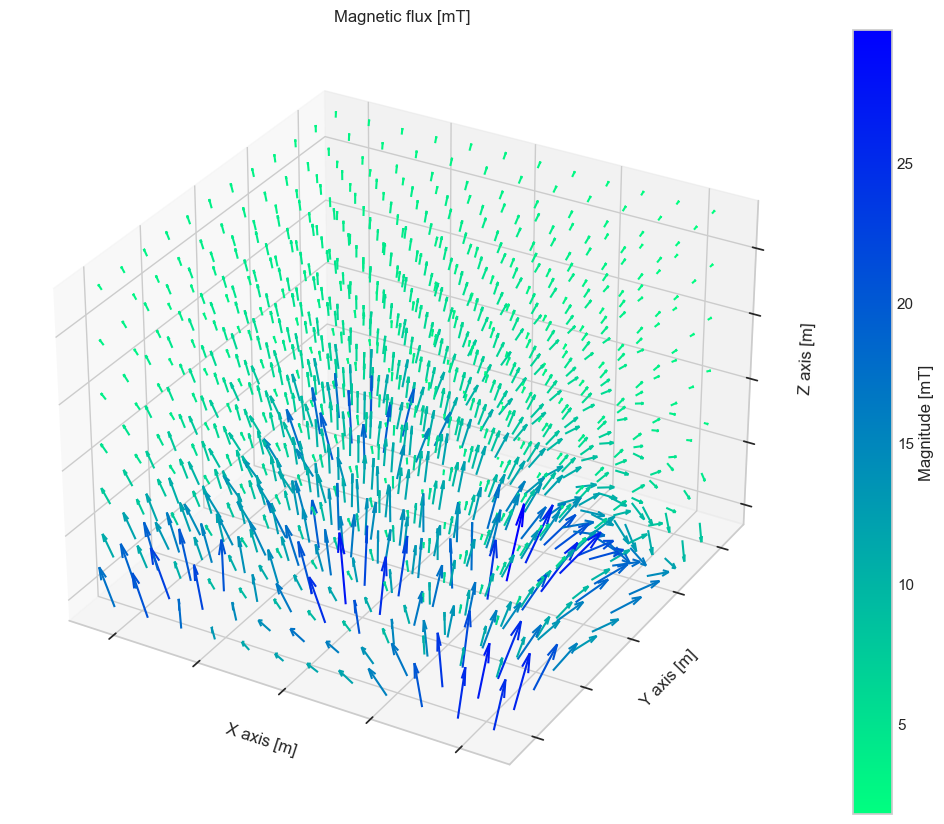

RMSE: tensor([1.2816, 1.4600, 2.2075])
RMSE_norm: 1.9812155961990356
MAE: tensor([0.6952, 0.7971, 1.5881])
MAE_norm: 1.42793607711792
MAEP: tensor([0.7501, 4.5760, 0.4958])
MAEP_norm: 0.1733105629682541
phi_MAE: 0.10899274051189423 and in degrees: 6.244823455810547
theta_MAE: 0.16744378209114075 and degrees: 9.59382152557373


In [289]:
Analyze_model(df1_clean)

47.539577


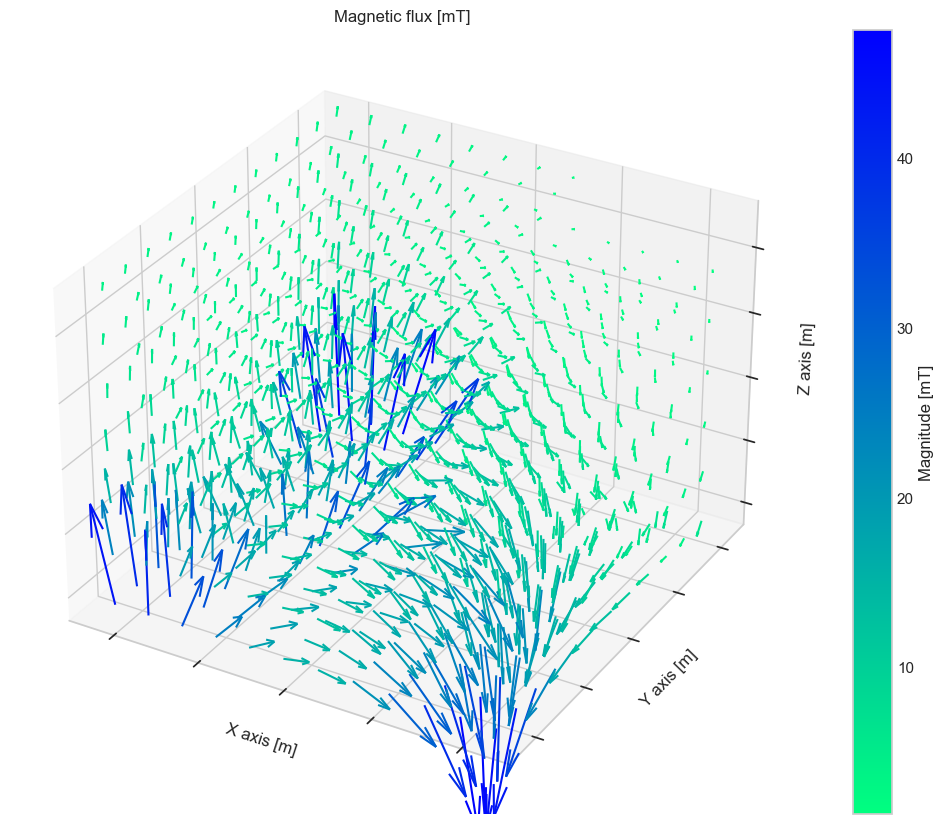

RMSE: tensor([2.2543, 1.8866, 2.4027])
RMSE_norm: 2.411858081817627
MAE: tensor([1.1250, 1.0881, 1.2145])
MAE_norm: 1.267500400543213
MAEP: tensor([0.3834, 3.4339, 0.6450])
MAEP_norm: 0.10976060479879379
phi_MAE: 0.10018318146467209 and in degrees: 5.740073204040527
theta_MAE: 0.18286974728107452 and degrees: 10.47766399383545


In [290]:
Analyze_model(df2_clean)

54.70291


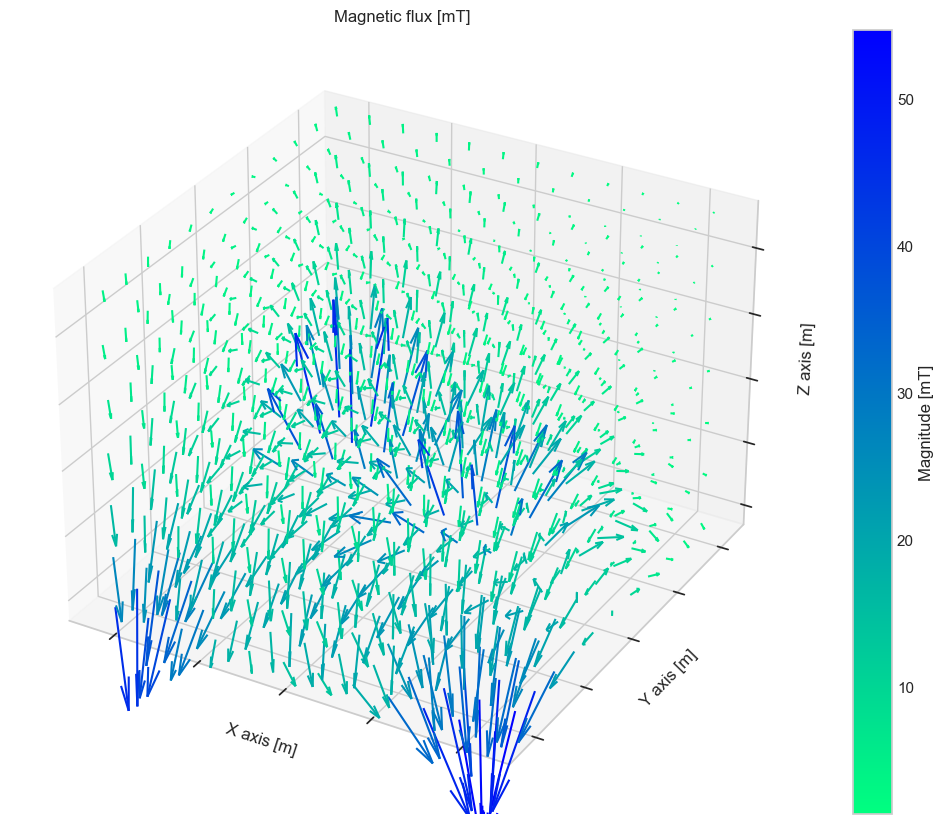

RMSE: tensor([1.5495, 1.5939, 2.2285])
RMSE_norm: 2.274320125579834
MAE: tensor([0.9071, 0.9793, 1.2357])
MAE_norm: 1.2342822551727295
MAEP: tensor([1.7397, 0.4735, 1.1342])
MAEP_norm: 0.09717052429914474
phi_MAE: 0.10418061167001724 and in degrees: 5.969109058380127
theta_MAE: 0.1414274126291275 and degrees: 8.103193283081055


In [291]:
Analyze_model(df3_clean)

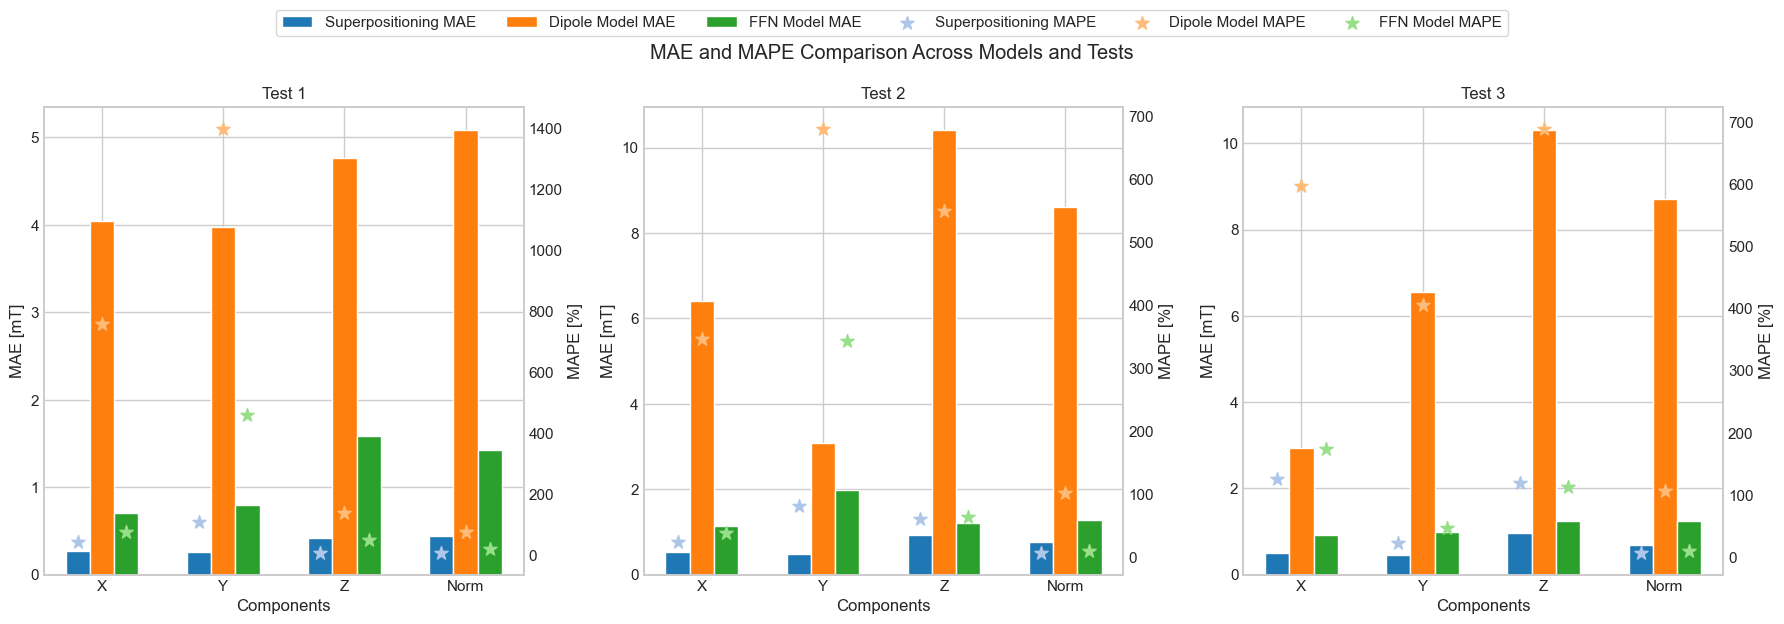

In [263]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["X", "Y", "Z", "Norm"]
tests = ["Test 1", "Test 2", "Test 3"]

# MAE data
superpositioning_MAE = [
    [0.27, 0.52, 0.51],
    [0.26, 0.47, 0.45],
    [0.42, 0.92, 0.96],
    [0.44, 0.77, 0.68],
    [1.47, 3.92, 4.5],
    [5.06, 4.90, 5.0]
]

dipole_MAE = [
    [4.04, 6.40, 2.93],
    [3.97, 3.07, 6.55],
    [4.76, 10.42, 10.32],
    [5.09, 8.61, 8.70],
    [20.60, 54.49, 54.26],
    [58.30, 32.63, 37.7]
]

ffn_MAE = [
    [0.70, 1.13, 0.91],
    [0.80, 1.99, 0.98],
    [1.59, 1.21, 1.24],
    [1.43, 1.27, 1.23],
    [6.24, 5.74, 5.97],
    [9.58, 10.47, 8.10]
]

# MAPE data
superpositioning_MAPE = [
    [42.2, 25.1, 125.7],
    [106.4, 82.5, 22.2],
    [6.1, 61.3, 118.8],
    [4.6, 6.9, 6.1],
    [None, None, None],
    [None, None, None]
]

dipole_MAPE = [
    [758, 346, 597],
    [1400, 680, 405],
    [138, 549, 689],
    [73, 103, 107],
    [None, None, None],
    [None, None, None]
]

ffn_MAPE = [
    [75.01, 38.34, 173.9],
    [457.6, 343.39, 47.35],
    [49.58, 64.50, 113.42],
    [17.33, 10.97, 9.7],
    [None, None, None],
    [None, None, None]
]

models = ["Superpositioning", "Dipole Model", "FFN Model"]
MAE_data = [superpositioning_MAE, dipole_MAE, ffn_MAE]
MAPE_data = [superpositioning_MAPE, dipole_MAPE, ffn_MAPE]

# Define custom colors for each model
MAE_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # Blue, Orange, Green
MAPE_colors = ["#aec7e8", "#ffbb78", "#98df8a"]  # Light variants of the same colors

# Plot configuration
bar_width = 0.2
x = np.arange(len(categories))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for i, ax in enumerate(axes):
    ax2 = ax.twinx()  # Secondary axis for MAPE

    # Plot MAE for each model with custom colors
    for j, model in enumerate(models):
        ax.bar(x + j * bar_width, [MAE_data[j][k][i] for k in range(len(categories))],
               width=bar_width, color=MAE_colors[j], label=f"{model} MAE" if i == 0 else "")

    # Plot MAPE as lines with markers and custom colors
    for j, model in enumerate(models):
        ax2.scatter(x + j * bar_width, [MAPE_data[j][k][i] if MAPE_data[j][k][i] is not None else np.nan 
                                     for k in range(len(categories))],
                 marker='*', s = 100, color=MAPE_colors[j],
                 label=f"{model} MAPE" if i == 0 else "")

    # Labels and titles
    ax.set_title(tests[i])
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(categories)
    ax.set_xlabel("Components")
   
    ax.set_ylabel("MAE [mT]")
    ax2.set_ylabel("MAPE [%]")
    ax.grid(True)
    ax2.grid(False)

# Global legend
fig.legend(loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("MAE and MAPE Comparison Across Models and Tests")
plt.tight_layout()
plt.show()
